# HW 2: Wrangling

**Q1.** This question provides some practice cleaning variables which have common problems.
1. Numeric variable: For `./data/airbnb_hw.csv`, clean the `Price` variable as well as you can, and explain the choices you make. How many missing values do you end up with? (Hint: What happens to the formatting when a price goes over 999 dollars, say from 675 to 1,112?)
2. Categorical variable: For the Minnesota police use of for data, `./data/mn_police_use_of_force.csv`, clean the `subject_injury` variable, handling the NA's; this gives a value `Yes` when a person was injured by police, and `No` when no injury occurred. What proportion of the values are missing? Is this a concern? Cross-tabulate your cleaned `subject_injury` variable with the `force_type` variable. Are there any patterns regarding when the data are missing?
3. Dummy variable: For the pretrial data covered in the lecture, clean the `WhetherDefendantWasReleasedPretrial` variable as well as you can, and, in particular, replace missing values with `np.nan`.
4. Missing values, not at random: For the pretrial data covered in the lecture, clean the `ImposedSentenceAllChargeInContactEvent` variable as well as you can, and explain the choices you make. (Hint: Look at the `SentenceTypeAllChargesAtConvictionInContactEvent` variable.)

In [11]:
# 1
# Numeric variable: For ./data/airbnb_hw.csv, clean the Price variable as well as you can, and explain the choices you make.
# How many missing values do you end up with? (Hint: What happens to the formatting when a price goes over 999 dollars, say from 675 to 1,112?)

# First, import packages
import pandas as pd
import numpy as np

# Load data
airbnb = pd.read_csv('https://raw.githubusercontent.com/dylanmulieri/wrangling/refs/heads/main/assignment/data/airbnb_hw.csv')

# Create copy to work with
airbnb_df = airbnb.copy()

# Look at df
display(airbnb_df.head())
display(airbnb_df.info())
display(airbnb_df.describe())

# Clean 'Price'
display(airbnb_df['Price']) # look at price
display(airbnb_df['Price'].isna().sum()) # check for missing values
# Price contains no missing variables

# Search for "$" or " " or "," in Price
display(airbnb_df[airbnb_df['Price'].str.contains('$')])
display(airbnb_df[airbnb_df['Price'].str.contains(' ')])
display(airbnb_df[airbnb_df['Price'].str.contains(',')])

# Remove "," and " "
airbnb_df['Price'] = airbnb_df['Price'].str.replace(',', '')

# Check that they were removed
display(airbnb_df[airbnb_df['Price'].str.contains(' ')])
display(airbnb_df[airbnb_df['Price'].str.contains(',')])

'''
There were no NA values in 'Price' variable.
The only cleaning I had to do was removing " " and ",".
'''

,Host Id,Host Since,Name,Neighbourhood,Property Type,Review Scores Rating (bin),Room Type,Zipcode,Beds,Number of Records,Number Of Reviews,Price,Review Scores Rating
0,5162530,NaN,1 Bedroom in Prime Williamsburg,Brooklyn,Apartment,NaN,Entire home/apt,11249.0,1.0,1,0,145,NaN
1,33134899,NaN,"Sunny, Private room in Bushwick",Brooklyn,Apartment,NaN,Private room,11206.0,1.0,1,1,37,NaN
2,39608626,NaN,Sunny Room in Harlem,Manhattan,Apartment,NaN,Private room,10032.0,1.0,1,1,28,NaN
3,500,6/26/2008,Gorgeous 1 BR with Private Balcony,Manhattan,Apartment,NaN,Entire home/apt,10024.0,3.0,1,0,199,NaN
4,500,6/26/2008,Trendy Times Square Loft,Manhattan,Apartment,95.0,Private room,10036.0,3.0,1,39,549,96.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30478 entries, 0 to 30477
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Host Id                     30478 non-null  int64  
 1   Host Since                  30475 non-null  object 
 2   Name                        30478 non-null  object 
 3   Neighbourhood               30478 non-null  object 
 4   Property Type               30475 non-null  object 
 5   Review Scores Rating (bin)  22155 non-null  float64
 6   Room Type                   30478 non-null  object 
 7   Zipcode                     30344 non-null  float64
 8   Beds                        30393 non-null  float64
 9   Number of Records           30478 non-null  int64  
 10  Number Of Reviews           30478 non-null  int64  
 11  Price                       30478 non-null  object 
 12  Review Scores Rating        22155 non-null  float64
dtypes: float64(4), int64(3), object

None

,Host Id,Review Scores Rating (bin),Zipcode,Beds,Number of Records,Number Of Reviews,Review Scores Rating
count,3.047800e+04,22155.000000,30344.000000,30393.000000,30478.0,30478.000000,22155.000000
mean,1.273171e+07,90.738659,10584.854831,1.530089,1.0,12.018735,91.993230
std,1.190270e+07,9.059519,921.299397,1.015359,0.0,21.980703,8.850373
min,5.000000e+02,20.000000,1003.000000,0.000000,1.0,0.000000,20.000000
25%,2.701298e+06,85.000000,10017.000000,1.000000,1.0,0.000000,89.000000
50%,8.551693e+06,90.000000,10065.000000,1.000000,1.0,3.000000,94.000000
75%,2.120617e+07,100.000000,11216.000000,2.000000,1.0,13.000000,100.000000
max,4.303307e+07,100.000000,99135.000000,16.000000,1.0,257.000000,100.000000


,Price
0,145
1,37
2,28
3,199
4,549
...,...
30473,300
30474,125
30475,80
30476,35


...

,Host Id,Host Since,Name,Neighbourhood,Property Type,Review Scores Rating (bin),Room Type,Zipcode,Beds,Number of Records,Number Of Reviews,Price,Review Scores Rating


,Host Id,Host Since,Name,Neighbourhood,Property Type,Review Scores Rating (bin),Room Type,Zipcode,Beds,Number of Records,Number Of Reviews,Price,Review Scores Rating
101,8730,2/27/2009,Comfort & Convenience,Manhattan,Condominium,100.0,Entire home/apt,10003.0,6.0,1,4,"1,990",100.0
263,34915,8/30/2009,Luxurious 2-Floor Manhattan Mansion,Manhattan,Apartment,NaN,Entire home/apt,10075.0,2.0,1,0,"1,000",NaN
764,112879,4/23/2010,Modern Luxury Meets Old Money Charm,Brooklyn,Apartment,NaN,Entire home/apt,11206.0,5.0,1,0,"1,200",NaN
1272,214148,8/26/2010,"LARGE, COMFY 1BDR W/CHARACTER!!!",Brooklyn,Apartment,90.0,Entire home/apt,11216.0,1.0,1,30,"1,000",92.0
1275,213266,8/26/2010,Beautiful 1 Bedroom in Nolita/Soho,Manhattan,Apartment,75.0,Entire home/apt,10012.0,2.0,1,2,"5,000",76.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
28951,37155810,6/30/2015,Central Park Luxury : 115916,Manhattan,Apartment,NaN,Entire home/apt,10019.0,2.0,1,0,"3,390",NaN
28952,37155810,6/30/2015,Central Park South Place : 112756,Manhattan,Apartment,NaN,Entire home/apt,10019.0,1.0,1,0,"1,356",NaN
28953,37155810,6/30/2015,Central Park South Views : 112754,Manhattan,Apartment,NaN,Entire home/apt,10019.0,1.0,1,0,"2,599",NaN
28985,37241813,7/1/2015,VERY Spacious 3BR in East Village,Manhattan,Apartment,NaN,Entire home/apt,10009.0,3.0,1,0,"2,000",NaN


,Host Id,Host Since,Name,Neighbourhood,Property Type,Review Scores Rating (bin),Room Type,Zipcode,Beds,Number of Records,Number Of Reviews,Price,Review Scores Rating


,Host Id,Host Since,Name,Neighbourhood,Property Type,Review Scores Rating (bin),Room Type,Zipcode,Beds,Number of Records,Number Of Reviews,Price,Review Scores Rating


'\n\n'

In [15]:
# 2
# Categorical variable: For the Minnesota police use of for data, ./data/mn_police_use_of_force.csv, clean the subject_injury variable, handling the NA's;
# this gives a value Yes when a person was injured by police, and No when no injury occurred.
# What proportion of the values are missing? Is this a concern?
# Cross-tabulate your cleaned subject_injury variable with the force_type variable.
# Are there any patterns regarding when the data are missing?

# Load the data
mn_police = pd.read_csv("https://raw.githubusercontent.com/dylanmulieri/wrangling/refs/heads/main/assignment/data/mn_police_use_of_force.csv")

# Create copy
mn_police_df = mn_police.copy()

# Explore data
display(mn_police_df.head())
display(mn_police_df.info())
display(mn_police_df.describe())

# Look at and clean 'subject_injury variable
display(mn_police_df['subject_injury'].head())
display(mn_police_df['subject_injury'].isna().sum()) # There are 9848 NA values
# What percent of 'subject_injury' data is NA
display(mn_police_df['subject_injury'].isna().sum() / len(mn_police_df['subject_injury'])) # About 76%

# So much data is missing from thsi column that it cannot be reasonably cleaned or used with predictive power

# Cross-tabulate 'subject_injury' with 'force_type'
display(pd.crosstab(mn_police_df['subject_injury'], mn_police_df['force_type']))

'''
From the cross-tabulation we can gather:
subjects were more likely to be injured than not for Baton, Bodily Force, Gun Point Display, Improvised Weapon, Less Lethal Projectile, Police K9 Bite, and Taser
Subjects were more likely not to be injured than to be injured for Chemical Irritant and Firearm
Note that these conclusions are near meaningless with about 3 quarters of the data missing.
'''

,response_datetime,problem,is_911_call,primary_offense,subject_injury,force_type,force_type_action,race,sex,age,type_resistance,precinct,neighborhood
0,2016/01/01 00:47:36,Assault in Progress,Yes,DASLT1,NaN,Bodily Force,Body Weight to Pin,Black,Male,20.0,Tensed,1,Downtown East
1,2016/01/01 02:19:34,Fight,No,DISCON,NaN,Chemical Irritant,Personal Mace,Black,Female,27.0,Verbal Non-Compliance,1,Downtown West
2,2016/01/01 02:19:34,Fight,No,DISCON,NaN,Chemical Irritant,Personal Mace,White,Female,23.0,Verbal Non-Compliance,1,Downtown West
3,2016/01/01 02:28:48,Fight,No,PRIORI,NaN,Chemical Irritant,Crowd Control Mace,Black,Male,20.0,Commission of Crime,1,Downtown West
4,2016/01/01 02:28:48,Fight,No,PRIORI,NaN,Chemical Irritant,Crowd Control Mace,Black,Male,20.0,Commission of Crime,1,Downtown West


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12925 entries, 0 to 12924
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   response_datetime  12925 non-null  object 
 1   problem            12925 non-null  object 
 2   is_911_call        12925 non-null  object 
 3   primary_offense    12925 non-null  object 
 4   subject_injury     3077 non-null   object 
 5   force_type         12925 non-null  object 
 6   force_type_action  12925 non-null  object 
 7   race               11901 non-null  object 
 8   sex                12424 non-null  object 
 9   age                11859 non-null  float64
 10  type_resistance    9939 non-null   object 
 11  precinct           12925 non-null  int64  
 12  neighborhood       12921 non-null  object 
dtypes: float64(1), int64(1), object(11)
memory usage: 1.3+ MB


None

,age,precinct
count,11859.000000,12925.000000
mean,29.484527,2.809981
std,10.987780,1.519432
min,0.000000,0.000000
25%,22.000000,1.000000
50%,28.000000,3.000000
75%,35.000000,4.000000
max,82.000000,5.000000


,subject_injury
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN


np.int64(9848)

np.float64(0.7619342359767892)

force_type,Baton,Bodily Force,Chemical Irritant,Firearm,Gun Point Display,Improvised Weapon,Less Lethal Projectile,Police K9 Bite,Taser
subject_injury,,,,,,,,,
No,0,1093,131,2,33,34,1,2,150
Yes,2,1286,41,0,44,40,2,44,172


In [46]:
# 3
# Dummy variable: For the pretrial data covered in the lecture, clean the WhetherDefendantWasReleasedPretrial variable as well as you can,
# and, in particular, replace missing values with np.nan.


# load the data
pretrial = pd.read_parquet("/content/justice_data (3).parquet")

# create copy
pretrial_df = pretrial.copy()

# explore the data
display(pretrial_df.head())
display(pretrial_df.info())
display(pretrial_df.describe())

# explore WhetherDefendantWasReleasedPretrial
display(pretrial_df['WhetherDefendantWasReleasedPretrial'])
display(pretrial_df["WhetherDefendantWasReleasedPretrial"].isna().sum()) # No NAs, but '9' values exist
display(pretrial_df['WhetherDefendantWasReleasedPretrial'].value_counts()) # Check for data that does not make sense
# the presence of 31 9s does not make sense, treat them as NA
# Replace 9s using np.nan and assign the result back to the column
pretrial_df["WhetherDefendantWasReleasedPretrial"] = pretrial_df["WhetherDefendantWasReleasedPretrial"].replace(9, np.nan)

# Check value counts again to confirm the replacement
display(pretrial_df["WhetherDefendantWasReleasedPretrial"].value_counts(dropna=False))
display(pretrial_df["WhetherDefendantWasReleasedPretrial"].isna().sum()) # Check for 31 NaN values -- yes

#--------------------------------------------------------------------------------------------------------------------------------------------------

# 4
# Missing values, not at random: For the pretrial data covered in the lecture,
# clean the ImposedSentenceAllChargeInContactEvent variable as well as you can, and explain the choices you make.
# (Hint: Look at the SentenceTypeAllChargesAtConvictionInContactEvent variable.)

# explore ImposedSentenceAllChargeInContactEvent
display(pretrial_df['ImposedSentenceAllChargeInContactEvent'])
display(pretrial_df['ImposedSentenceAllChargeInContactEvent'].isna().sum()) # This shows 0 NAs, but there are blank values
display(pretrial_df['ImposedSentenceAllChargeInContactEvent'].value_counts(dropna=False)) # Check for data that does not make sense
display(pretrial_df['ImposedSentenceAllChargeInContactEvent'].unique()) # blank values are " " strings
# Check count of " "
display(pretrial_df['ImposedSentenceAllChargeInContactEvent'].value_counts(dropna=False)[' ']) # 9053
# What percent of the total data is this?
display(pretrial_df['ImposedSentenceAllChargeInContactEvent'].value_counts(dropna=False)[' '] / len(pretrial_df['ImposedSentenceAllChargeInContactEvent']))
# about 39% of the data is blank aka NA

# replace " " with NA
pretrial_df['ImposedSentenceAllChargeInContactEvent'] = pretrial_df['ImposedSentenceAllChargeInContactEvent'].replace(" ", np.nan)
display(pretrial_df['ImposedSentenceAllChargeInContactEvent'].value_counts(dropna=False)) # Check -- worked

# Are these NAs related to another column?
# Filter to show rows where 'ImposedSentenceAllChargeInContactEvent' is NaN
missing_imposed_sentence = pretrial_df[pretrial_df['ImposedSentenceAllChargeInContactEvent'].isna()]
display(missing_imposed_sentence)

# look at the value counts of 'SentenceTypeAllChargesAtConvictionInContactEvent' for these filtered rows, appears connected
display(missing_imposed_sentence['SentenceTypeAllChargesAtConvictionInContactEvent'].value_counts(dropna=False))

# Also, display a sample of these rows to visually confirm
display(missing_imposed_sentence[['ImposedSentenceAllChargeInContactEvent', 'SentenceTypeAllChargesAtConvictionInContactEvent']].head(20))

# data is missing from ImposedSentenceAllChargeInContactEvent when SentenceTypeAllChargesAtConvictionInContactEvent is 4 or 9

,InternalStudyID,REQ_REC#,Defendant_Sex,Defendant_Race,Defendant_BirthYear,Defendant_Age,Defendant_AgeGroup,Defendant_AgeatCurrentArrest,Defendant_AttorneyTypeAtCaseClosure,Defendant_IndigencyStatus,...,NewFelonySexualAssaultArrest_OffDate,NewFelonySexualAssaultArrest_ArrestDate,NewFelonySexualAssaultArrest_DaysBetweenContactEventandOffDate,NewFelonySexualAssaultArrest_DaysBetweenOffDateandArrestDate,NewFelonySexualAssaultArrest_DaysBetweenReleaseDateandOffDate,NewFelonySexualAssaultArrest_Disposition,Intertnalindicator_ReasonforExcludingFromFollowUpAnalysis,CriminalHistoryRecordsReturnedorCMSRecordsFoundforIndividual,DispRecordFoundforChargesinOct2017Contact_Atleast1dispfound,CrimeCommission2021ReportClassificationofDefendants
0,ADI00001,1,M,W,1986,31,3,31,99,99,...,,,,999,999,,4,1,0,Defendant could not be classified or tracked d...
1,ADI00007,3,M,B,1956,60,6,60,9,9,...,,,,999,999,,5,1,1,Defendant Detained Entire Pre-Trial Period_Und...
2,ADI00008,4,M,W,1990,27,3,27,9,9,...,,,,999,999,,5,1,1,Defendant Detained Entire Pre-Trial Period_Und...
3,CDI00036,6,M,B,1989,27,3,27,0,0,...,,,,999,999,,5,1,1,Defendant Detained Entire Pre-Trial Period_Und...
4,CDI00038,7,F,W,1988,28,3,28,0,0,...,,,,999,999,,0,1,1,New criminal offense punishable by incarcerati...


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22986 entries, 0 to 22985
Columns: 709 entries, InternalStudyID to CrimeCommission2021ReportClassificationofDefendants
dtypes: int64(63), object(646)
memory usage: 124.3+ MB


None

,Defendant_AgeGroup,Defendant_AttorneyTypeAtCaseClosure,Defendant_IndigencyStatus,WhetherDefendantWasReleasedPretrial,DaysBetweenContactEventAndPretrialRelease,PretrialReleaseType1,PretrialReleaseType2,BondTypeAtInitialContact,BondTypeAtRelease_v1,BondTypeatRelease_v2,...,NewPSAViolentMisdArrest_DaysBetweenOffDateandArrestDate,NewPSAViolentMisdArrest_DaysBetweenReleaseDateandOffDate,NewVaCode805ViolentOff_DaysBetweenOffDateandArrestDate,NewVaCode805ViolentOff_DaysBetweenReleaseDateandOffDate,NewVaCode297ViolentOff_DaysBetweenOffDateandArrestDate,NewVaCode297ViolentOff_DaysBetweenReleaseDateandOffDate,NewFelonySexualAssaultArrest_DaysBetweenOffDateandArrestDate,NewFelonySexualAssaultArrest_DaysBetweenReleaseDateandOffDate,Intertnalindicator_ReasonforExcludingFromFollowUpAnalysis,DispRecordFoundforChargesinOct2017Contact_Atleast1dispfound
count,22986.000000,22986.000000,22986.000000,22986.000000,22986.000000,22986.000000,22986.000000,22986.000000,22986.000000,22986.000000,...,22986.000000,22986.000000,22986.000000,22986.000000,22986.000000,22986.000000,22986.000000,22986.000000,22986.000000,22986.000000
mean,3.391543,3.303750,1.927869,0.845428,175.066301,2.731619,1.872444,3.113330,3.282041,3.192030,...,972.448882,975.656704,981.714609,984.377969,992.571087,993.530497,998.310928,998.452188,0.983903,1.009615
std,1.293381,10.713382,10.779928,0.477276,374.426546,2.078630,1.663620,1.866408,1.788788,1.775506,...,159.714176,143.844743,128.708975,114.253166,78.964332,70.252286,25.512519,22.329630,1.667225,0.403211
min,2.000000,0.000000,0.000000,0.000000,-18.000000,0.000000,0.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,0.000000,0.000000
25%,2.000000,1.000000,0.000000,1.000000,0.000000,2.000000,1.000000,1.000000,2.000000,2.000000,...,999.000000,999.000000,999.000000,999.000000,999.000000,999.000000,999.000000,999.000000,0.000000,1.000000
50%,3.000000,2.000000,0.000000,1.000000,0.000000,3.000000,2.000000,3.000000,3.000000,3.000000,...,999.000000,999.000000,999.000000,999.000000,999.000000,999.000000,999.000000,999.000000,0.000000,1.000000
75%,4.000000,4.000000,1.000000,1.000000,6.000000,4.000000,3.000000,4.000000,4.000000,3.000000,...,999.000000,999.000000,999.000000,999.000000,999.000000,999.000000,999.000000,999.000000,1.000000,1.000000
max,9.000000,99.000000,99.000000,9.000000,999.000000,9.000000,9.000000,9.000000,9.000000,9.000000,...,999.000000,999.000000,999.000000,999.000000,999.000000,999.000000,999.000000,999.000000,9.000000,9.000000


,WhetherDefendantWasReleasedPretrial
0,9
1,0
2,0
3,0
4,1
...,...
22981,1
22982,1
22983,1
22984,1


...

np.float64(0.3938484294788132)

,count
ImposedSentenceAllChargeInContactEvent,
NaN,9053
0,4953
12,1404
.985626283367556,1051
6,809
...,...
11.9055441478439,1
35.0061601642711,1
46.6242299794661,1


,InternalStudyID,REQ_REC#,Defendant_Sex,Defendant_Race,Defendant_BirthYear,Defendant_Age,Defendant_AgeGroup,Defendant_AgeatCurrentArrest,Defendant_AttorneyTypeAtCaseClosure,Defendant_IndigencyStatus,...,NewFelonySexualAssaultArrest_OffDate,NewFelonySexualAssaultArrest_ArrestDate,NewFelonySexualAssaultArrest_DaysBetweenContactEventandOffDate,NewFelonySexualAssaultArrest_DaysBetweenOffDateandArrestDate,NewFelonySexualAssaultArrest_DaysBetweenReleaseDateandOffDate,NewFelonySexualAssaultArrest_Disposition,Intertnalindicator_ReasonforExcludingFromFollowUpAnalysis,CriminalHistoryRecordsReturnedorCMSRecordsFoundforIndividual,DispRecordFoundforChargesinOct2017Contact_Atleast1dispfound,CrimeCommission2021ReportClassificationofDefendants
0,ADI00001,1,M,W,1986,31,3,31,99,99,...,,,,999,999,,4,1,0,Defendant could not be classified or tracked d...
4,CDI00038,7,F,W,1988,28,3,28,0,0,...,,,,999,999,,0,1,1,New criminal offense punishable by incarcerati...
11,CDI00050,14,M,B,1992,25,2,25,4,0,...,,,,999,999,,5,1,1,Defendant Detained Entire Pre-Trial Period_Und...
12,CDI00055,15,F,W,1982,35,3,35,4,0,...,,,,999,999,,0,1,1,New criminal offense punishable by incarcerati...
15,CDI00089,18,F,W,1979,38,4,38,1,1,...,,,,999,999,,0,1,1,New criminal offense punishable by incarcerati...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22981,SJA00343,22839,M,B,1976,41,4,41,2,1,...,,,,999,999,,0,1,1,New criminal offense punishable by incarcerati...
22982,SJA00344,,F,W,,,9,,99,99,...,,,,999,999,,3,,9,Defendant could not be classified or tracked d...
22983,SJA00345,22841,M,B,1981,36,4,36,1,1,...,,,,999,999,,0,1,1,New criminal offense punishable by incarcerati...
22984,SJA00346,22842,F,B,1993,24,2,24,5,0,...,,,,999,999,,0,1,1,New criminal offense punishable by incarcerati...


,count
SentenceTypeAllChargesAtConvictionInContactEvent,
4,8779
9,274


,ImposedSentenceAllChargeInContactEvent,SentenceTypeAllChargesAtConvictionInContactEvent
0,NaN,9
4,NaN,4
11,NaN,4
12,NaN,4
15,NaN,4
16,NaN,4
18,NaN,4
21,NaN,4
22,NaN,4
24,NaN,4


**Q2.** Go to https://sharkattackfile.net/ and download their dataset on shark attacks.

1. Open the shark attack file using Pandas. It is probably not a csv file, so `read_csv` won't work.
2. Drop any columns that do not contain data.
3. Clean the year variable. Describe the range of values you see. Filter the rows to focus on attacks since 1940. Are attacks increasing, decreasing, or remaining constant over time?
4. Clean the Age variable and make a histogram of the ages of the victims.
5. What proportion of victims are male?
6. Clean the `Type` variable so it only takes three values: Provoked and Unprovoked and Unknown. What proportion of attacks are unprovoked?
7. Clean the `Fatal Y/N` variable so it only takes three values: Y, N, and Unknown.
8. Are sharks more likely to launch unprovoked attacks on men or women? Is the attack more or less likely to be fatal when the attack is provoked or unprovoked? Is it more or less likely to be fatal when the victim is male or female? How do you feel about sharks?
9. What proportion of attacks appear to be by white sharks? (Hint: `str.split()` makes a vector of text values into a list of lists, split by spaces.)

,Date,Year,Type,Country,State,Location,Activity,Name,Sex,Age,...,Species,Source,pdf,href formula,href,Case Number,Case Number.1,original order,Unnamed: 21,Unnamed: 22
0,29th January,2026.0,Unprovoked,Brazil,Recife,Del Chifre Beach in Olinda,Swimming,Deivson Rocha Dantas,M,13,...,Unknown bull and tiger sharks frequent the area,Kevin McMurray Trackingsharks.com: TV Globo: P...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,29th January,2026.0,Unprovoked,Australia,NSW,Angels Beach East Ballina,Surfing,Unnamed man,M,?,...,Unknown,Bob Myatt GSAF,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,24th January,2026.0,Unprovoked,Australia,Tasmania,Cooee Beach west of Burnie,Swimming,Megan Stokes,F,?,...,1.7m Seven Gill shark,Bob Myatt GSAF,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,20th January,2026.0,Unprovoked,Australia,NSW,Point Plomber North of Port Macquarie,Surfing,Paul Zvirdinas,M,39,...,Bull shark,Bob Myatt GSAF,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,19th January,2026.0,Unprovoked,Australia,NSW,Dee Why,Surfing,Unknown,M,11,...,Bull shark,Andy Currie,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7074 entries, 0 to 7073
Data columns (total 23 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            7074 non-null   object 
 1   Year            7072 non-null   float64
 2   Type            7056 non-null   object 
 3   Country         7024 non-null   object 
 4   State           6587 non-null   object 
 5   Location        6507 non-null   object 
 6   Activity        6491 non-null   object 
 7   Name            6856 non-null   object 
 8   Sex             6496 non-null   object 
 9   Age             4080 non-null   object 
 10  Injury          7039 non-null   object 
 11  Fatal Y/N       6513 non-null   object 
 12  Time            3547 non-null   object 
 13  Species         3943 non-null   object 
 14  Source          7054 non-null   object 
 15  pdf             6799 non-null   object 
 16  href formula    6794 non-null   object 
 17  href            6796 non-null   o

None

,Year,original order
count,7072.000000,6799.000000
mean,1936.004242,3401.152081
std,270.672015,1963.076319
min,0.000000,2.000000
25%,1948.000000,1701.500000
50%,1987.000000,3401.000000
75%,2010.000000,5100.500000
max,2026.000000,6802.000000


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7074 entries, 0 to 7073
Data columns (total 23 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            7074 non-null   object 
 1   Year            7072 non-null   float64
 2   Type            7056 non-null   object 
 3   Country         7024 non-null   object 
 4   State           6587 non-null   object 
 5   Location        6507 non-null   object 
 6   Activity        6491 non-null   object 
 7   Name            6856 non-null   object 
 8   Sex             6496 non-null   object 
 9   Age             4080 non-null   object 
 10  Injury          7039 non-null   object 
 11  Fatal Y/N       6513 non-null   object 
 12  Time            3547 non-null   object 
 13  Species         3943 non-null   object 
 14  Source          7054 non-null   object 
 15  pdf             6799 non-null   object 
 16  href formula    6794 non-null   object 
 17  href            6796 non-null   o

...

array([2026., 2016., 2025., 2024., 2023., 2022., 2021., 2020., 2019.,
       2018., 2017., 2015., 2014., 2013., 2012., 2011., 2010., 2009.,
       2008., 2007., 2006., 2005., 2004., 2003., 2002., 2001., 2000.,
       1999., 1998., 1997., 1996., 1995., 1984., 1994., 1993., 1992.,
       1991., 1990., 1989., 1969., 1988., 1987., 1986., 1985., 1983.,
       1982., 1981., 1980., 1979., 1978., 1977., 1976., 1975., 1974.,
       1973., 1972., 1971., 1970., 1968., 1967., 1966., 1965., 1964.,
       1963., 1962., 1961., 1960., 1959., 1958., 1957., 1956., 1955.,
       1954., 1953., 1952., 1951., 1950., 1949., 1948., 1848., 1947.,
       1946., 1945., 1944., 1943., 1942., 1941., 1940., 1939., 1938.,
       1937., 1936., 1935., 1934., 1933., 1932., 1931., 1930., 1929.,
       1928., 1927., 1926., 1925., 1924., 1923., 1922., 1921., 1920.,
       1919., 1918., 1917., 1916., 1915., 1914., 1913., 1912., 1911.,
       1910., 1909., 1908., 1907., 1906., 1905., 1904., 1903., 1902.,
       1901., 1900.,

array([2026., 2016., 2025., 2024., 2023., 2022., 2021., 2020., 2019.,
       2018., 2017., 2015., 2014., 2013., 2012., 2011., 2010., 2009.,
       2008., 2007., 2006., 2005., 2004., 2003., 2002., 2001., 2000.,
       1999., 1998., 1997., 1996., 1995., 1984., 1994., 1993., 1992.,
       1991., 1990., 1989., 1969., 1988., 1987., 1986., 1985., 1983.,
       1982., 1981., 1980., 1979., 1978., 1977., 1976., 1975., 1974.,
       1973., 1972., 1971., 1970., 1968., 1967., 1966., 1965., 1964.,
       1963., 1962., 1961., 1960., 1959., 1958., 1957., 1956., 1955.,
       1954., 1953., 1952., 1951., 1950., 1949., 1948., 1848., 1947.,
       1946., 1945., 1944., 1943., 1942., 1941., 1940., 1939., 1938.,
       1937., 1936., 1935., 1934., 1933., 1932., 1931., 1930., 1929.,
       1928., 1927., 1926., 1925., 1924., 1923., 1922., 1921., 1920.,
       1919., 1918., 1917., 1916., 1915., 1914., 1913., 1912., 1911.,
       1910., 1909., 1908., 1907., 1906., 1905., 1904., 1903., 1902.,
       1901., 1900.,

526.0

,Date,Year,Type,Country,State,Location,Activity,Name,Sex,Age,...,Species,Source,pdf,href formula,href,Case Number,Case Number.1,original order,Unnamed: 21,Unnamed: 22
0,29th January,2026.0,Unprovoked,Brazil,Recife,Del Chifre Beach in Olinda,Swimming,Deivson Rocha Dantas,M,13,...,Unknown bull and tiger sharks frequent the area,Kevin McMurray Trackingsharks.com: TV Globo: P...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,29th January,2026.0,Unprovoked,Australia,NSW,Angels Beach East Ballina,Surfing,Unnamed man,M,?,...,Unknown,Bob Myatt GSAF,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,24th January,2026.0,Unprovoked,Australia,Tasmania,Cooee Beach west of Burnie,Swimming,Megan Stokes,F,?,...,1.7m Seven Gill shark,Bob Myatt GSAF,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,20th January,2026.0,Unprovoked,Australia,NSW,Point Plomber North of Port Macquarie,Surfing,Paul Zvirdinas,M,39,...,Bull shark,Bob Myatt GSAF,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,19th January,2026.0,Unprovoked,Australia,NSW,Dee Why,Surfing,Unknown,M,11,...,Bull shark,Andy Currie,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,Date,Year,Type,Country,State,Location,Activity,Name,Sex,Age,...,Species,Source,pdf,href formula,href,Case Number,Case Number.1,original order,Unnamed: 21,Unnamed: 22
5535,1940,1940.0,Unprovoked,NEW GUINEA,Bwagaoia,"Bagalina, North coast Misima Island",NaN,small girl,F,NaN,...,NaN,"A. Bleakley; A. M. Rapson, p.148",1940.00.00.e-small-girl.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,http://sharkattackfile.net/spreadsheets/pdf_di...,1940.00.00.e,1940.00.00.e,1535.0,NaN,NaN
5536,1940,1940.0,Unprovoked,PAPUA NEW GUINEA,Western Papuan Gulf,Kerema,male,a native,NaN,NaN,...,NaN,"Papuan Villager, 11/1940",1940.00.00.d-Kerema.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,http://sharkattackfile.net/spreadsheets/pdf_di...,1940.00.00.d,1940.00.00.d,1534.0,NaN,NaN
5537,1940,1940.0,Invalid,SOUTH AFRICA,Eastern Cape Province,Kidd's Beach,Swimming,NaN,NaN,NaN,...,Questionable incident,"D. Davies, p. 102",1940.00.00.c-KiddsBeach.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,http://sharkattackfile.net/spreadsheets/pdf_di...,1940.00.00.c,1940.00.00.c,1533.0,NaN,NaN
5538,1940,1940.0,Invalid,SOUTH AFRICA,KwaZulu-Natal,Winkelspruit,NaN,Indian female,F,NaN,...,Questionable incident,"V.M. Coppleson (1958), p.247; SAF Case #161. U...",1940.00.00.b-IndianFemale.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,http://sharkattackfile.net/spreadsheets/pdf_di...,1940.00.00.b,1940.00.00.b,1532.0,NaN,NaN
5539,1940,1940.0,Invalid,SOUTH AFRICA,Eastern Cape Province,"Kowie River Mouth, Port Alfred",Standing in water with child in her arms,female,F,NaN,...,Questionable incident,"E. Skaife, V. M. Coppleson (1958), p.247; M. ...",1940.00.00.a-Woman-Kowie.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,http://sharkattackfile.net/spreadsheets/pdf_di...,1940.00.00.a,1940.00.00.a,1531.0,NaN,NaN


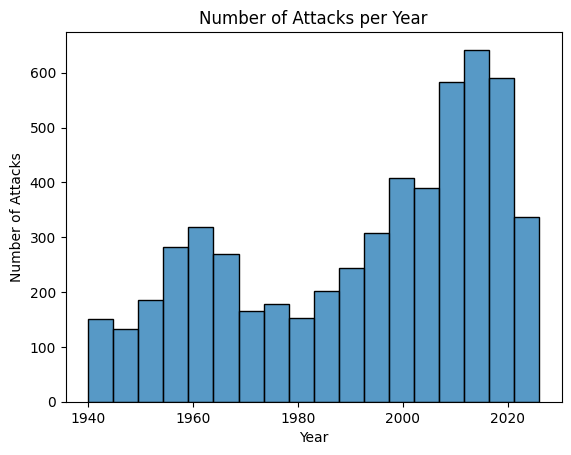

np.int64(2914)

np.float64(0.41988472622478384)

array([ 2.  ,   nan,  6.  ,  1.  ,  4.5 ,  1.5 ,  4.  ,  5.5 ,  5.  ,
        3.  ,  3.5 ,  2.5 ,  8.  ,  9.  ,  7.  ,  6.5 ,  7.5 ,  0.5 ,
       16.  ,  0.75,  0.25])

,count
Age_cleaned,
0.25,1
0.50,69
0.75,1
1.00,218
1.50,327
2.00,372
2.50,390
3.00,436
3.50,445


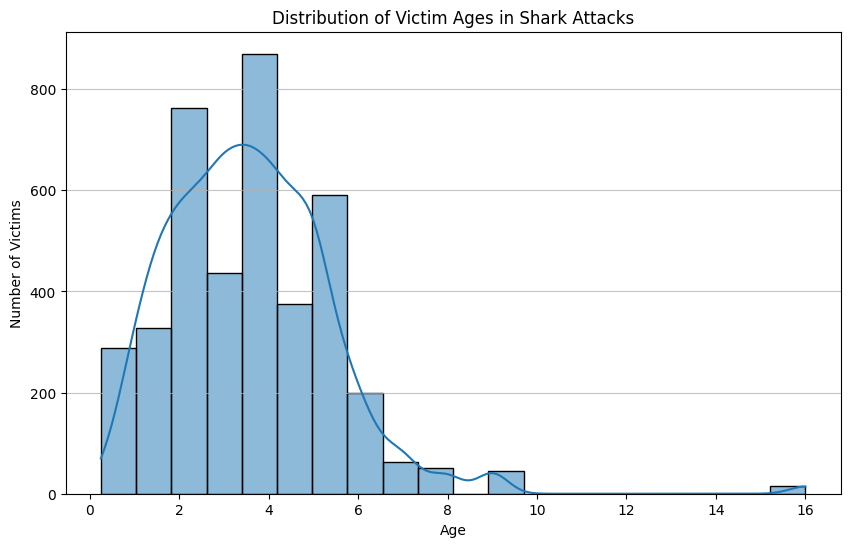

,count
Sex,
M,5560
F,796
NaN,570
M,4
F,2
N,2
m,1
M,1
lli,1


array(['M', 'F', 'F ', 'M ', nan, ' M', 'm', 'lli', '?', 'M x 2', 'N',
       '.'], dtype=object)

,count
Sex,
M,5565
F,798
NaN,570
N,2
m,1
lli,1
?,1
Mx2,1
.,1


array(['M', 'F', nan, 'm', 'lli', '?', 'Mx2', 'N', '.'], dtype=object)

,count
Sex,
M,5566
F,798
NaN,570
N,2
LLI,1
?,1
MX2,1
.,1


...

,count
Fatal Y/N,
N,4516
Y,1322
UNKNOWN,526


array(['Y', 'N', 'UNKNOWN'], dtype=object)

,count
Species,
NaN,2788
White shark,167
Invalid,87
Shark involvement prior to death was not confirmed,86
Shark involvement not confirmed,82
...,...
2 sharks,1
"4' ""ground shark""",1
Remains recovered from shark caught days later,1


array(['Unknown bull and tiger sharks frequent the area', 'Unknown',
       '1.7m Seven Gill shark', ...,
       '"The fish was harpooned, dried, and presented to the sailor, who went round Europe exhibiting it  It was said to be 20 feet long.',
       'White shark, 1600-lb female ', 'Possibly white sharks'],
      dtype=object)

np.float64(0.09726587052168448)

In [108]:
# 1
# Import packages
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data
shark = pd.read_excel("/content/GSAF5.xls")

# Make a copy
shark_df = shark.copy()

# look at head to ensure it worked
display(shark_df.head())

# 2
# Look at the data
display(shark_df.info())
display(shark_df.describe())

# Drop any columns that do not contain data.
shark_df.dropna(axis=1, how='all', inplace=True)

display(shark_df.info()) # No columns appear to have been dropped, all must contain data

# 3
# Clean the year variable. Describe the range of values you see.
# Filter the rows to focus on attacks since 1940.
# Are attacks increasing, decreasing, or remaining constant over time?

# Clean Year
display(shark_df['Year'])
display(shark_df['Year'].isna().sum()) # 2 NA values

# Drop the two NA rows
shark_df.dropna(subset=['Year'], inplace=True)

# doublecheck for NAs
display(shark_df['Year'].isna().sum())

# Check for other types of NA; data that does not make sense like numbers not in the 1000s
display(shark_df['Year'].unique())
# 1000, 77, 5, and zero all likely inaccurate and should be dropped

# Drop 0 rows
shark_df = shark_df[shark_df['Year'] != 0]
# drop 5 rows
shark_df = shark_df[shark_df['Year'] != 5]
# drop 77 rows
shark_df = shark_df[shark_df['Year'] != 77]
# drop 1000 rows
shark_df = shark_df[shark_df['Year'] != 1000]

# Check
display(shark_df['Year'].unique())

# WHat is the range of values
shark_range = shark_df['Year'].max() - shark_df['Year'].min()
display(shark_range) # Range is 526 years

# Filter data to 1940 to 2026
sharks_1940_2026 = shark_df[(shark_df['Year'] >= 1940)]
display(sharks_1940_2026.head())
display(sharks_1940_2026.tail())

# WHat has ahppened to attacks over time?

# Graph number of attacks per year for each year histogram
sns.histplot(sharks_1940_2026['Year'])
plt.xlabel('Year')
plt.ylabel('Number of Attacks')
plt.title('Number of Attacks per Year')
plt.show()

'''
After 1940, attacks increased until 1960, then decreased until 1980, then increased to a greater peak than 1960 in abou 2015,
then has been decreasing since to present day 2026.
'''

# 4
# Clean the Age variable and make a histogram of the ages of the victims.

# Define a function to clean and convert age values
def clean_age(age_str):
    if pd.isna(age_str):
        return np.nan
    age_str = str(age_str).lower().strip()

    # Handle specific patterns first
    # e.g., '18 months' -> 1.5 years
    month_match = re.search(r'(\d+)\s*months?', age_str)
    if month_match:
        return int(month_match.group(1)) / 12

    # e.g., '2-3 years', '20-25'
    range_match = re.search(r'(\d+)\s*[--]?\s*(\d+)', age_str)
    if range_match:
        age1 = int(range_match.group(1))
        age2 = int(range_match.group(2))
        return (age1 + age2) / 2

    # e.g., '30s', 'teen'
    if 'teen' in age_str:
        return 16 # Approximate average teen age
    if 's' in age_str and age_str.replace('s', '').isdigit():
        decade_start = int(age_str.replace('s', ''))
        return decade_start + 5 # Approximate midpoint of the decade

    # Extract first sequence of digits
    digit_match = re.search(r'\d+', age_str)
    if digit_match:
        return int(digit_match.group(0))

    return np.nan # If no pattern matches, return NaN

'''
Utilized Gemini to help build this function dude to the extreme variance in formats for the age data
'''
# Use the function on Age
shark_df['Age_cleaned'] = shark_df['Age'].apply(clean_age)

# Check the number of NA values after cleaning
display(shark_df['Age_cleaned'].isna().sum())

# What percent of the data is this
display(shark_df['Age_cleaned'].isna().sum() / len(shark_df['Age_cleaned']))

# Check for safety
display(shark_df['Age_cleaned'].unique())
display(shark_df['Age_cleaned'].value_counts(dropna=False).sort_index())

# Make a histogram of the ages of the victims
plt.figure(figsize=(10, 6))
sns.histplot(shark_df['Age_cleaned'].dropna(), bins=20, kde=True)
plt.title('Distribution of Victim Ages in Shark Attacks')
plt.xlabel('Age')
plt.ylabel('Number of Victims')
plt.grid(axis='y', alpha=0.75)
plt.show()

# 5
# What proportion of victims are male?

# See what data is in Sex
display(shark_df['Sex'].value_counts(dropna=False))
display(shark_df['Sex'].unique())

# Remove ' ' from any data
shark_df['Sex'] = shark_df['Sex'].str.replace(' ', '')

# Check
display(shark_df['Sex'].value_counts(dropna=False))
display(shark_df['Sex'].unique())

# Capitalize all data
shark_df['Sex'] = shark_df['Sex'].str.upper()

# Check
display(shark_df['Sex'].value_counts(dropna=False))
display(shark_df['Sex'].unique())

# Remove data that isnt F or M
shark_df = shark_df[shark_df['Sex'].isin(['F', 'M'])]

# Check
display(shark_df['Sex'].value_counts(dropna=False))
display(shark_df['Sex'].unique())
# 5566 Male to 798 Female. 87% male

# 6
# Clean the Type variable so it only takes three values: Provoked and Unprovoked and Unknown. What proportion of attacks are unprovoked?

# See data in Type
display(shark_df['Type'].value_counts(dropna=False))
display(shark_df['Type'].unique())

# Remove any " " and make all lowercase
shark_df['Type'] = shark_df['Type'].str.replace(' ', '').str.lower()

# Check
display(shark_df['Type'].value_counts(dropna=False))
display(shark_df['Type'].unique())

# Make data that is not "unprovoked" or "provoked" as "unknown"
valid_types = ['unprovoked', 'provoked']
shark_df['Type'] = shark_df['Type'].apply(lambda x: x if x in valid_types else 'unknown')

# Check
display(shark_df['Type'].value_counts(dropna=False))

# Calculate the proportion of unprovoked attacks
unprovoked_proportion = shark_df['Type'].value_counts(normalize=True)['unprovoked']
# About 78%

# 7
# Clean the Fatal Y/N variable so it only takes three values: Y, N, and Unknown.

# see data in Fatal Y/N
display(shark_df['Fatal Y/N'].value_counts(dropna=False))
display(shark_df['Fatal Y/N'].unique())

# Remove " " and capitalize all
shark_df['Fatal Y/N'] = shark_df['Fatal Y/N'].str.replace(' ', '').str.upper()

# Check
display(shark_df['Fatal Y/N'].value_counts(dropna=False))
display(shark_df['Fatal Y/N'].unique())

# Convert any value taht isnt Y or N to UNKNOWN
valid_types = ['Y', 'N']
shark_df['Fatal Y/N'] = shark_df['Fatal Y/N'].apply(lambda x: x if x in valid_types else 'UNKNOWN')

# Check
display(shark_df['Fatal Y/N'].value_counts(dropna=False))
display(shark_df['Fatal Y/N'].unique())

# 8
# Are sharks more likely to launch unprovoked attacks on men or women?
# Group type and sex
shark_df.groupby(['Type', 'Sex']).size()
# Unprovoked attacks are more likely against men

# Is the attack more or less likely to be fatal when the attack is provoked or unprovoked?
# Group Fatal Y/N and Type
shark_df.groupby(['Fatal Y/N', 'Type']).size()
# More likely to be fatal when unprovoked than provoked

# Is it more or less likely to be fatal when the victim is male or female?
# group Fatal Y/N and Sex
shark_df.groupby(['Fatal Y/N', 'Sex']).size()
# More likely to be fatal when the victim is male

# How do you feel about sharks?
# Sharks are cool. I always liked hammerheads. I was afraid to go snorkling with nurse sharks when I was younger though.

# 9
# What proportion of attacks appear to be by white sharks? (Hint: str.split() makes a vector of text values into a list of lists, split by spaces.)

# Look at species
display(shark_df['Species '].value_counts(dropna=False))
display(shark_df['Species '].unique())

# convert Species to lowercase and strip " "
shark_df['Species_cleaned'] = shark_df['Species '].astype(str).str.lower().str.strip()

# Separate White Shark
white_shark_attacks = shark_df[shark_df['Species_cleaned'].str.contains('white shark', na=False)]

# Calculate the amount of white shark attacks
num_white_shark_attacks = len(white_shark_attacks)

# Calculate the total number of non-missing species entries
total_species_entries = shark_df['Species_cleaned'].count()

# Calculate the proportion
proportion_white_shark = num_white_shark_attacks / total_species_entries
display(proportion_white_shark) # About 10% of attacks



**Q3.** Open the "tidy_data.pdf" document in the repo, which is a paper called Tidy Data by Hadley Wickham.

  1. Read the abstract. What is this paper about?
  2. Read the introduction. What is the "tidy data standard" intended to accomplish?
  3. Read the intro to section 2. What does this sentence mean: "Like families, tidy datasets are all alike but every messy dataset is messy in its own way." What does this sentence mean: "For a given dataset, it’s usually easy to figure out what are observations and what are variables, but it is surprisingly difficult to precisely define variables and observations in general."
  4. Read Section 2.2. How does Wickham define values, variables, and observations?
  5. How is "Tidy Data" defined in section 2.3?
  6. Read the intro to Section 3 and Section 3.1. What are the 5 most common problems with messy datasets? Why are the data in Table 4 messy? What is "melting" a dataset?
  7. Why, specifically, is table 11 messy but table 12 tidy and "molten"?
  8. Read Section 6. What is the "chicken-and-egg" problem with focusing on tidy data? What does Wickham hope happens in the future with further work on the subject of data wrangling?

In [108]:
# 1
'''

'''